In [10]:
import pandas as pd
import sqlite3

## 1. connection

In [11]:
db = sqlite3.connect("../data/checking-logs.sqlite")

In [12]:
df = pd.read_sql("SELECT datetime AS datetime FROM pageviews WHERE uid LIKE 'user_%'", db, parse_dates="datetime")
df.head()

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144


## 2. Creating series

In [13]:
df['date'] = df['datetime'].dt.date
grouped_df = df.groupby('date').size().rename("count")
grouped_df.head()

date
2020-04-17     1
2020-04-18    23
2020-04-19    15
2020-04-21     3
2020-04-22     1
Name: count, dtype: int64

## 3. Painting

<Axes: title={'center': 'Views per Day'}, xlabel='date'>

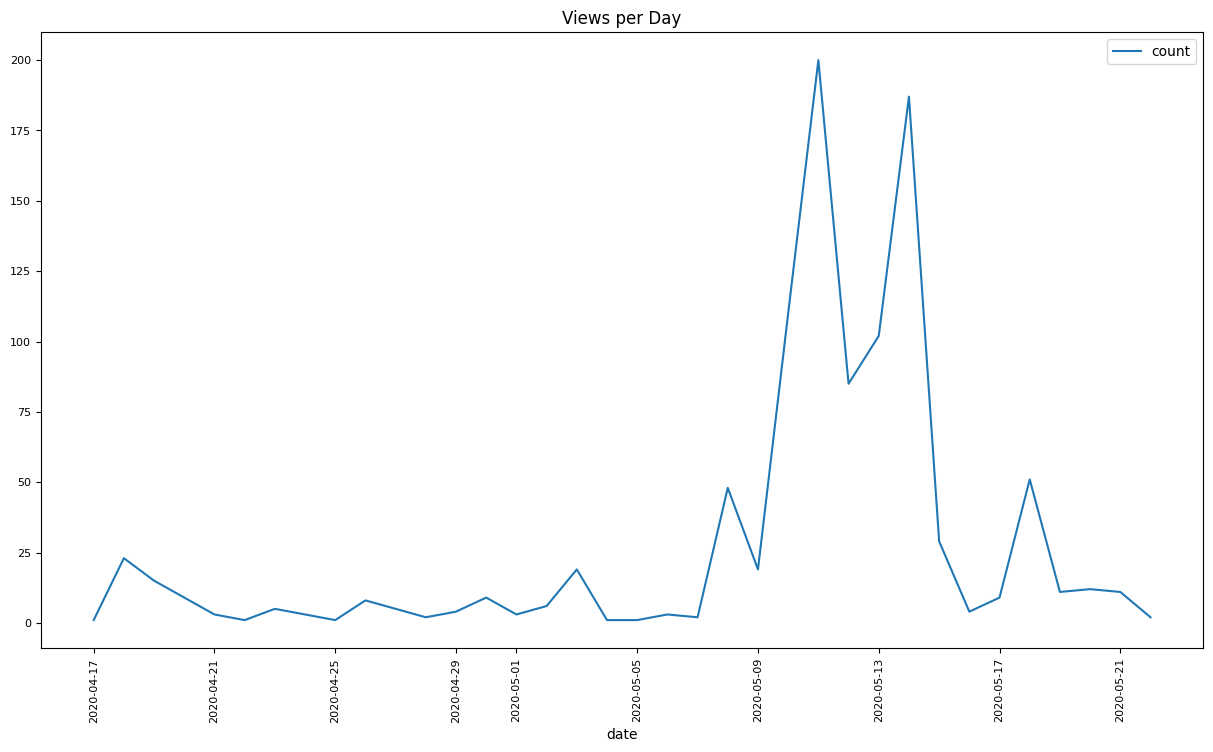

In [14]:
grouped_df.plot(fontsize = 8, figsize = (15,8), title="Views per Day", rot=90, legend=True)

## 4. Close

In [15]:
db.close()